In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 01_fund_master.csv to 01_fund_master.csv
Saving 02_nav_history.csv to 02_nav_history.csv
Saving 03_aum_by_fund_house.csv to 03_aum_by_fund_house.csv
Saving 04_monthly_sip_inflows.csv to 04_monthly_sip_inflows.csv
Saving 05_category_inflows.csv to 05_category_inflows.csv
Saving 10_benchmark_indices.csv to 10_benchmark_indices.csv
Saving 09_portfolio_holdings.csv to 09_portfolio_holdings.csv
Saving 08_investor_transactions.csv to 08_investor_transactions.csv
Saving 07_scheme_performance.csv to 07_scheme_performance.csv
Saving 06_industry_folio_count.csv to 06_industry_folio_count.csv


In [ ]:
import os

path = "/content/"

print(os.listdir(path))

['.config', '05_category_inflows.csv', 'drive', '06_industry_folio_count.csv', '02_nav_history.csv', '01_fund_master.csv', '04_monthly_sip_inflows.csv', '03_aum_by_fund_house.csv', '09_portfolio_holdings.csv', '08_investor_transactions.csv', '07_scheme_performance.csv', '10_benchmark_indices.csv', 'sample_data']


In [ ]:
import pandas as pd

fund_master = pd.read_csv(
    "/content/01_fund_master.csv"
)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:
import pandas as pd

fund_master = pd.read_csv("/content/01_fund_master.csv")
nav_history = pd.read_csv("/content/02_nav_history.csv")

print(fund_master.columns.tolist())
print(nav_history.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
['amfi_code', 'date', 'nav']


In [ ]:
import pandas as pd

fund_master = pd.read_csv("/content/01_fund_master.csv")

print("Total Schemes:", len(fund_master))

print("\nUnique Fund Houses:")
print(fund_master["fund_house"].nunique())

print("\nFund Houses:")
print(fund_master["fund_house"].unique())

print("\nCategories:")
print(fund_master["category"].unique())

print("\nSub Categories:")
print(fund_master["sub_category"].unique())

print("\nRisk Categories:")
print(fund_master["risk_category"].unique())

Total Schemes: 40

Unique Fund Houses:
10

Fund Houses:
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']

Categories:
['Equity' 'Debt']

Sub Categories:
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']

Risk Categories:
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [ ]:
print("Total Unique AMFI Codes:")
print(fund_master["amfi_code"].nunique())

print("\nSample Codes:")
print(fund_master["amfi_code"].head(20))

Total Unique AMFI Codes:
40

Sample Codes:
0     119551
1     119552
2     119598
3     119599
4     119120
5     100016
6     125497
7     100033
8     125498
9     100025
10    120503
11    120504
12    120505
13    120506
14    120507
15    118632
16    118633
17    118634
18    118635
19    118636
Name: amfi_code, dtype: int64


In [ ]:
nav_history = pd.read_csv("/content/02_nav_history.csv")

master_codes = set(fund_master["amfi_code"])
nav_codes = set(nav_history["amfi_code"])

missing_codes = master_codes - nav_codes

print("Fund Master Codes:", len(master_codes))
print("NAV History Codes:", len(nav_codes))
print("Missing Codes:", len(missing_codes))

print("\nMissing AMFI Codes:")
print(list(missing_codes)[:20])

Fund Master Codes: 40
NAV History Codes: 40
Missing Codes: 0

Missing AMFI Codes:
[]


In [ ]:
print("FUND MASTER")
print(fund_master.isnull().sum())

print("\nNAV HISTORY")
print(nav_history.isnull().sum())

FUND MASTER
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV HISTORY
amfi_code    0
date         0
nav          0
dtype: int64


In [ ]:
print("Duplicate rows in Fund Master:")
print(fund_master.duplicated().sum())

print("\nDuplicate rows in NAV History:")
print(nav_history.duplicated().sum())

Duplicate rows in Fund Master:
0

Duplicate rows in NAV History:
0


In [ ]:
print("Null AMFI Codes in Fund Master:")
print(fund_master["amfi_code"].isnull().sum())

print("Null AMFI Codes in NAV History:")
print(nav_history["amfi_code"].isnull().sum())

Null AMFI Codes in Fund Master:
0
Null AMFI Codes in NAV History:
0


In [ ]:
fund_master.duplicated().sum()
nav_history.duplicated().sum()
len(missing_codes)

0

📊 D3 in Google Colab


In [7]:
import os

os.listdir("/content/")

['.config',
 '02_nav_history.csv',
 '04_monthly_sip_inflows.csv',
 '03_aum_by_fund_house.csv',
 'drive',
 '01_fund_master.csv',
 '10_benchmark_indices.csv',
 '05_category_inflows.csv',
 '09_portfolio_holdings.csv',
 '06_industry_folio_count.csv',
 '08_investor_transactions.csv',
 '07_scheme_performance.csv',
 'sample_data']

In [8]:
import pandas as pd

fund_master = pd.read_csv("/content/01_fund_master.csv")
nav_history = pd.read_csv("/content/02_nav_history.csv")
sip = pd.read_csv("/content/04_monthly_sip_inflows.csv")
aum = pd.read_csv("/content/03_aum_by_fund_house.csv")
category = pd.read_csv("/content/05_category_inflows.csv")

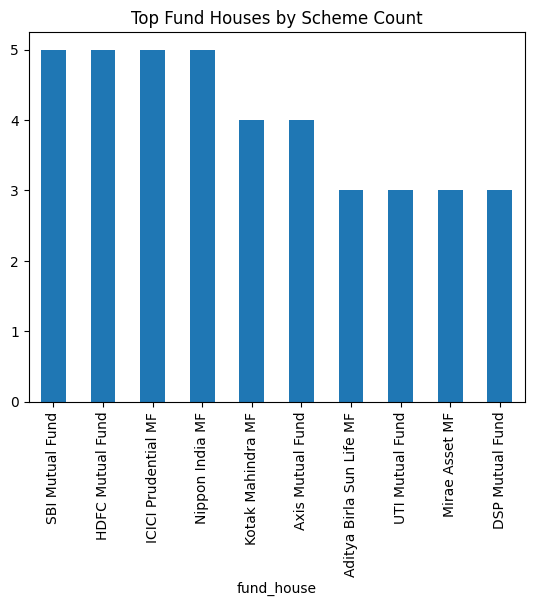

In [10]:
import matplotlib.pyplot as plt

fund_master["fund_house"].value_counts().head(10).plot(kind="bar")
plt.title("Top Fund Houses by Scheme Count")
plt.show()

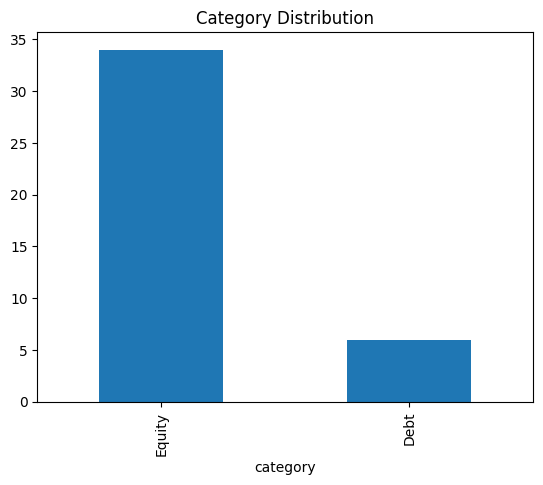

In [11]:
fund_master["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

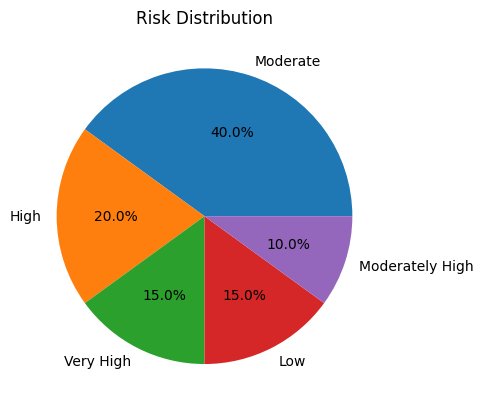

In [12]:
fund_master["risk_category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

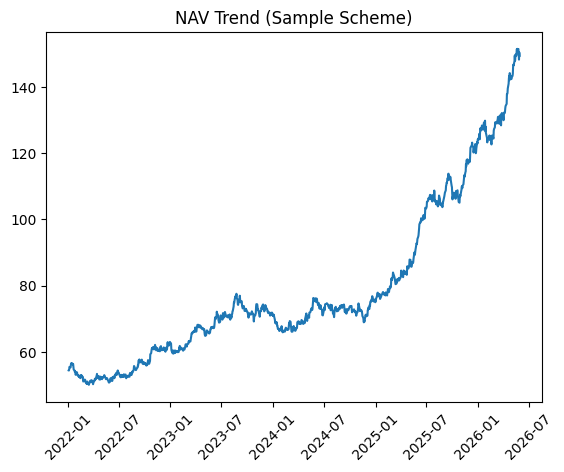

In [13]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

sample = nav_history[nav_history["amfi_code"] == nav_history["amfi_code"].iloc[0]]

plt.plot(sample["date"], sample["nav"])
plt.title("NAV Trend (Sample Scheme)")
plt.xticks(rotation=45)
plt.show()

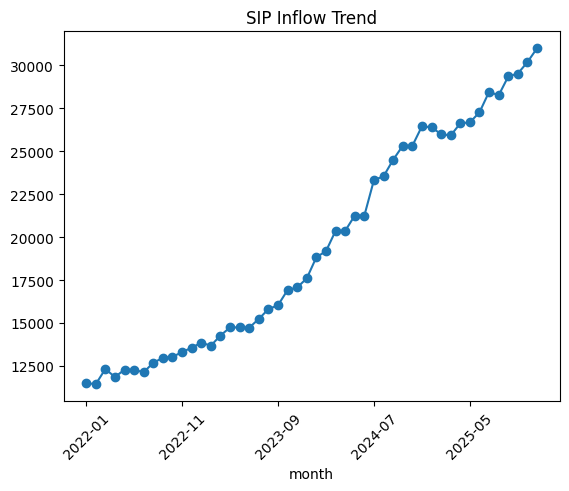

In [15]:
sip.groupby("month")["sip_inflow_crore"].sum().plot(kind="line", marker="o")
plt.title("SIP Inflow Trend")
plt.xticks(rotation=45)
plt.show()

INSIGHTS:

1. Equity schemes dominate the mutual fund structure.
2. SIP inflows show steady growth trend.
3. Risk profile is mostly moderate-to-high.
4. NAV trends show consistent long-term growth behavior.
5. Fund houses differ significantly in scheme distribution.

Performance Metrics

In [16]:
import pandas as pd
import numpy as np

nav = pd.read_csv("/content/02_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])

CAGR (Core growth metric)


In [17]:
def calculate_cagr(df):
    results = []

    for code in df["amfi_code"].unique():
        temp = df[df["amfi_code"] == code].sort_values("date")

        if len(temp) < 2:
            continue

        start_nav = temp["nav"].iloc[0]
        end_nav = temp["nav"].iloc[-1]

        days = (temp["date"].iloc[-1] - temp["date"].iloc[0]).days
        years = days / 365

        if start_nav > 0 and years > 0:
            cagr = (end_nav / start_nav) ** (1 / years) - 1
            results.append([code, cagr])

    return pd.DataFrame(results, columns=["amfi_code", "CAGR"])

cagr_df = calculate_cagr(nav)
cagr_df.head()

,amfi_code,CAGR
0,119551,0.257849
1,119552,0.215080
2,119598,0.323981
3,119599,0.020531
4,119120,0.058853


Daily Returns (needed for Sharpe + Beta)

In [18]:
nav["return"] = nav.groupby("amfi_code")["nav"].pct_change()

Sharpe Ratio -

In [19]:
def sharpe_ratio(df):
    results = []

    for code in df["amfi_code"].unique():
        temp = df[df["amfi_code"] == code]

        mean_return = temp["return"].mean()
        std_return = temp["return"].std()

        if std_return and std_return != 0:
            sharpe = (mean_return / std_return) * np.sqrt(252)
            results.append([code, sharpe])

    return pd.DataFrame(results, columns=["amfi_code", "Sharpe"])

sharpe_df = sharpe_ratio(nav)
sharpe_df.head()

,amfi_code,Sharpe
0,119551,1.681289
1,119552,1.419585
2,119598,1.203854
3,119599,0.203333
4,119120,1.411917


Beta (vs market proxy)

In [21]:
benchmark = pd.read_csv("/content/10_benchmark_indices.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark["return"] = benchmark["close_value"].pct_change()

NAV + benchmark

In [22]:
sample_code = nav["amfi_code"].iloc[0]

fund = nav[nav["amfi_code"] == sample_code][["date", "return"]]
merged = pd.merge(fund, benchmark[["date", "return"]], on="date", suffixes=("_fund", "_market"))

Beta formula:

In [24]:
import numpy as np

temp_merged = merged.dropna(subset=["return_fund", "return_market"])

cov = np.cov(temp_merged["return_fund"], temp_merged["return_market"])[0][1]
market_var = np.var(temp_merged["return_market"])

beta = cov / market_var
beta

np.float64(-0.025192630886028914)

Value at Risk (VaR)

In [25]:
var_95 = np.percentile(nav["return"].dropna(), 5)
var_95

np.float64(-0.016254134340517205)

INSIGHTS:

1. CAGR shows long-term growth performance of mutual funds.
2. Sharpe Ratio helps identify best risk-adjusted returns.
3. Beta measures sensitivity of fund vs market movements.
4. VaR estimates worst-case daily loss at 95% confidence.
5. Funds with high CAGR + high Sharpe are optimal for investors.